In [1]:
## in terminal
# python3 -m pip install --upgrade pip
# python3 -m pip --version
# python3 -m pip install numpy matplotlib pandas scikit-learn seaborn jupyterlab

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

illustrate changes in metric values (recall, precision, accuracy, specificity, f1-score) at different prevalence (prior probability)

In [3]:
# set variables
recall = 0.9 # how many true positives are correctly identified
specificity = 0.95 # how many true negatives are correctly identified
prevalence = np.linspace(0.01, 0.99, 100) # diff probability

# # confusion matrix
# TP = prevalence * recall # true positives
# FP = (1 - prevalence) * (1 - specificity) # false positives
# TN = (1 - prevalence) * specificity # true negatives
# FN = prevalence * (1 - recall) # false negatives

In [4]:
# results for each probability

results = []

for p in prevalence:
    # confusion matrix
    TP = p * recall # true positives
    FP = (1 - p) * (1 - specificity) # false positives
    TN = (1 - p) * specificity # true negatives
    FN = p * (1 - recall) # false negatives

    precision = TP / (TP + FP) # how many predicted positives are true positives (PPV)
    accuracy = (TP + TN) / (TP + FP + TN + FN) # how many predictions are correct
    f1 = 2 * (precision * recall) / (precision + recall) # harmonic mean of precision and recall
    NPV = TN / (TN + FN) # how many predicted negatives are true negatives

    results.append([p, recall, specificity, precision, accuracy, f1, NPV])


In [5]:
# save results to dataframe
df = pd.DataFrame(results, columns=['Prevalence', 'Recall', 'Specificity', 'Precision', 'Accuracy', 'F1 Score', 'NPV'])
df.head()

,Prevalence,Recall,Specificity,Precision,Accuracy,F1 Score,NPV
0,0.010000,0.9,0.95,0.153846,0.949500,0.262774,0.998938
1,0.019899,0.9,0.95,0.267643,0.949005,0.412589,0.997867
2,0.029798,0.9,0.95,0.356017,0.948510,0.510209,0.996777
3,0.039697,0.9,0.95,0.426633,0.948015,0.578863,0.995667
4,0.049596,0.9,0.95,0.484354,0.947520,0.629779,0.994537


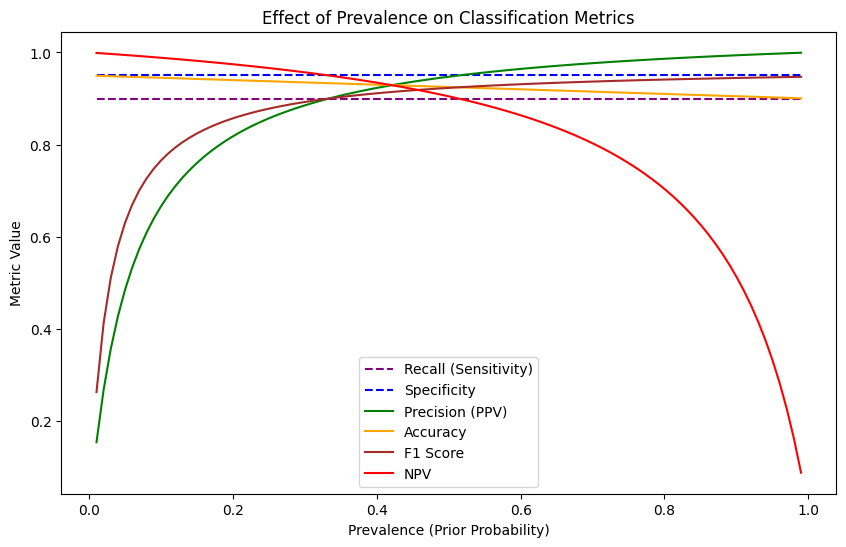

In [6]:
# plot the metrics

plt.figure(figsize=(10,6))

plt.plot(df['Prevalence'], df['Recall'], label = 'Recall (Sensitivity)', color='purple', linestyle='--')
plt.plot(df['Prevalence'], df['Specificity'], label = 'Specificity', color='blue', linestyle='--')

plt.plot(df['Prevalence'], df['Precision'], label = 'Precision (PPV)', color = 'green')
plt.plot(df['Prevalence'], df['Accuracy'], label = 'Accuracy', color = 'orange')
plt.plot(df['Prevalence'], df['F1 Score'], label = 'F1 Score', color = 'brown')
plt.plot(df['Prevalence'], df['NPV'], label = 'NPV', color = 'red')

plt.xlabel("Prevalence (Prior Probability)")
plt.ylabel("Metric Value")
plt.title("Effect of Prevalence on Classification Metrics")

plt.legend()
plt.show()